# TP1 - Teich Juan Ignacio

In [77]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import seaborn as sns

# Parte 1

El algorítmo **white-patch** normaliza al color de la luz blanca puro a partir de la transformación:
$$
(R,G,B) \Longrightarrow \left( \frac{255}{\max[R(x,y)]} R, \frac{255}{\max[G(x,y)]} G, \frac{255}{\max[B(x,y)]} B\right)
$$

In [ ]:
def white_patch(image):
    new_image = []
    for i in range(image.shape[-1]):
        # levantamos el canal segun i
        channel = image[:,:,i]
        # calculamos el maximo del canal y normalizamos segun white_patch
        max_channel = np.max(channel)
        norm_channel = np.uint8(channel * (255 / max_channel))
        # agregamos a new_image
        new_image.append(norm_channel)
    # devolvemos new_image con np.dstack para hacer de las dimensiones correctas
    return np.dstack(new_image)

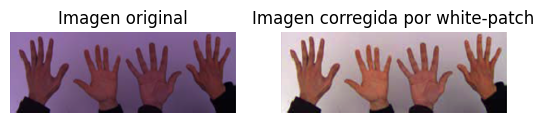

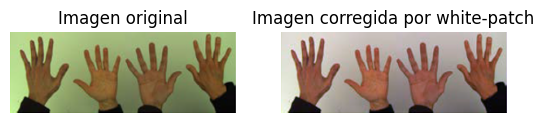

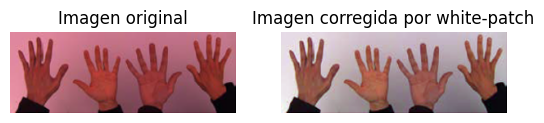

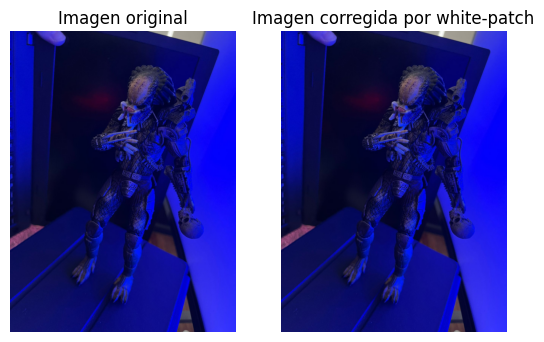

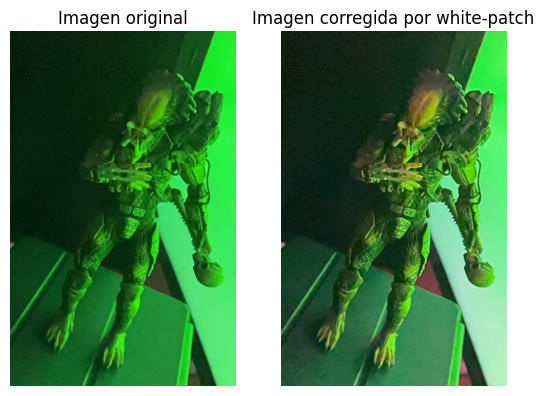

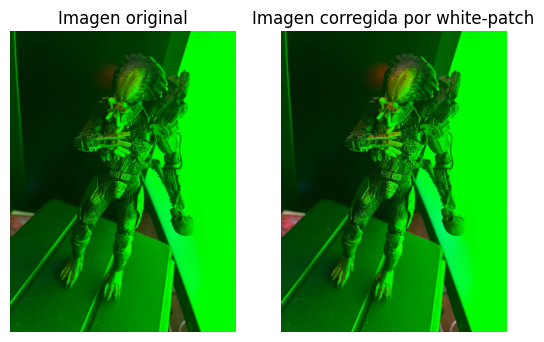

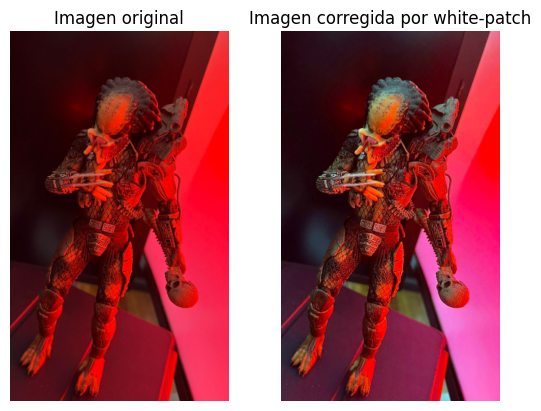

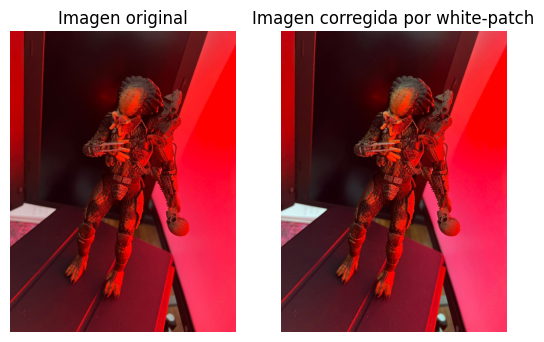

In [75]:
test_images = ['test_blue.png', 'test_green.png', 'test_red.png', 'wp_blue.jpg', 'wp_green.png', 'wp_green2.jpg', 'wp_red.png', 'wp_red2.jpg']

for img_path in test_images:
    img = cv.imread(f"white_patch/{img_path}")
    img_normalized = white_patch(img)

    fig, axs = plt.subplots(1,2)
    axs[0].imshow(img[:,:,::-1])
    axs[0].set_title('Imagen original')
    axs[1].imshow(img_normalized[:,:,::-1])
    axs[1].set_title('Imagen corregida por white-patch')

    for ax in axs:
        ax.axis('off')
    plt.show()

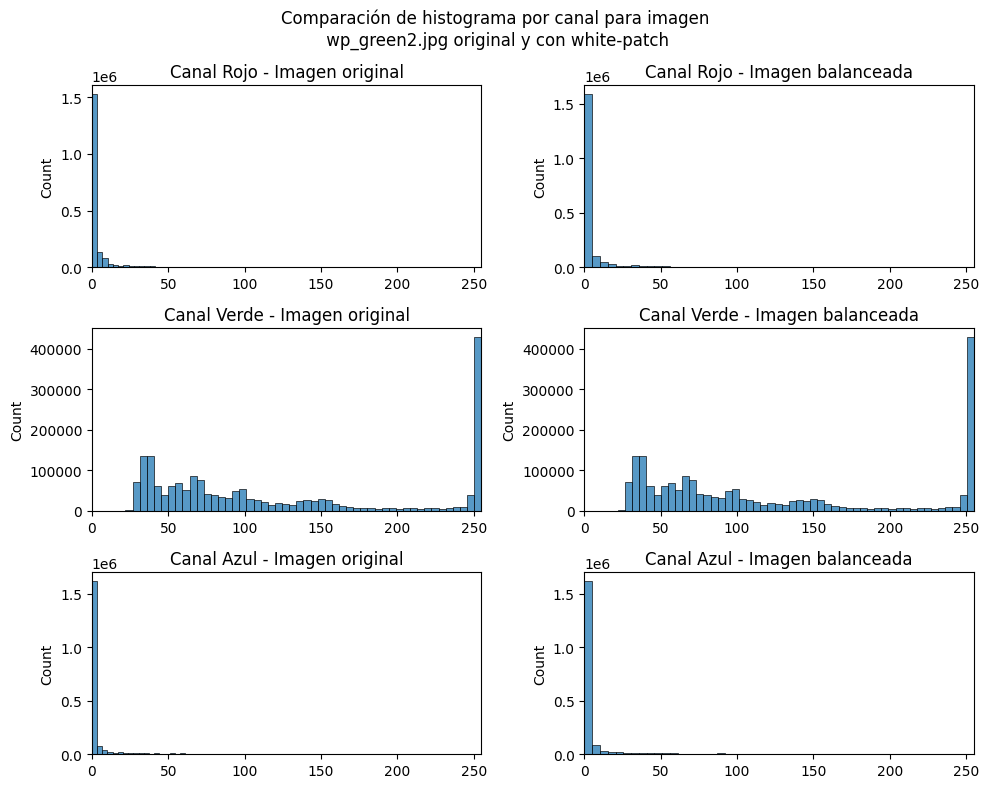

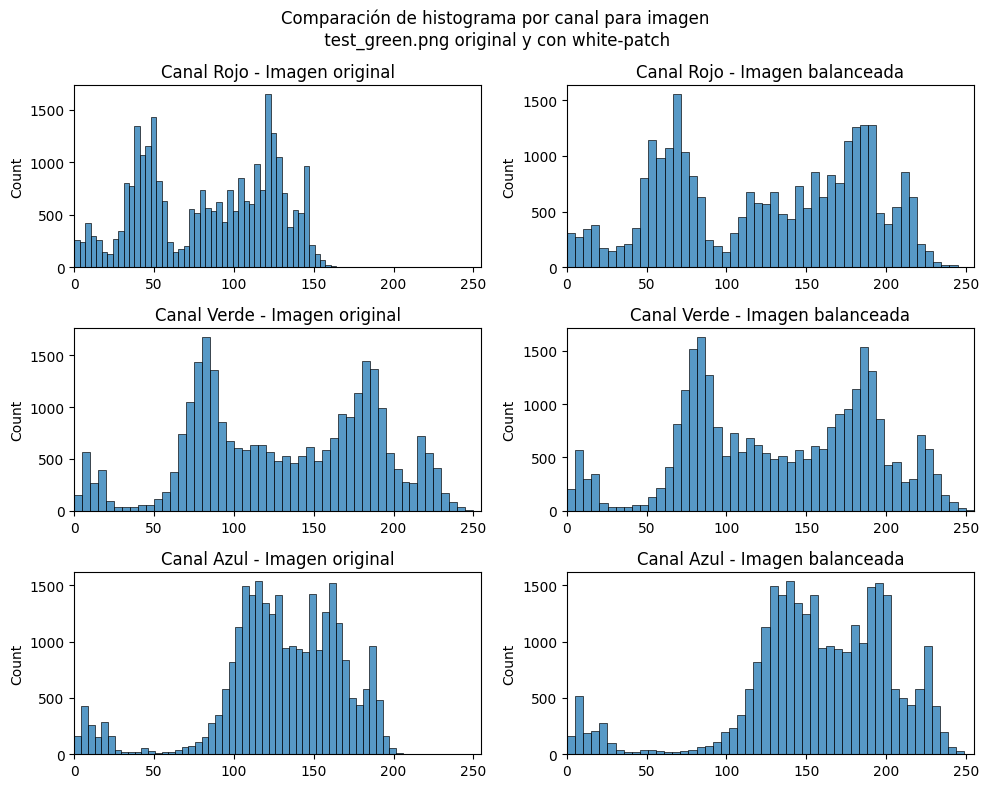

In [124]:
img_figura_verde_path = test_images[-3]
def compare_histograms(path):
    img_figura_verde = cv.imread(f"white_patch/{path}")
    fig, axs = plt.subplots(3,2, figsize=(10,8))
    titles = ['Canal Rojo', 'Canal Verde', 'Canal Azul']
    for i in range(3):
        sns.histplot(img_figura_verde[:,:,i].flatten(), ax=axs[i][0], bins=50)
        sns.histplot(white_patch(img_figura_verde)[:,:,i].flatten(), ax=axs[i][1], bins=50)
        [axs[i][j].set_xlim(0,255) for j in range(2)]
        axs[i][0].set_title(f"{titles[i]} - Imagen original")
        axs[i][1].set_title(f"{titles[i]} - Imagen balanceada")

    fig.suptitle(f'Comparación de histograma por canal para imagen\n {path} original y con white-patch')
    plt.tight_layout()
    plt.show()

compare_histograms(test_images[-3])
compare_histograms(test_images[1])

Se observa un muy buen comportamiento del algorítmo en las imágenes de las manos, logrando en los 3 casos imágenes mucho mejor balanceadas en color.

En el caso de la figura el algorítmo no logra diferencias tan importantes. Se logran mejoras apreciables en el caso de luz roja, aunque este caso aún sin normalización tiene buena nitidez. Luego en el caso de luz verde y azul la mejora es muy leve. 

Si vemos el histograma de cada canal para el caso de la imagen 'wd_green2.jpg', vemos que el canal rojo y azul tienen todos valores menores a 25, esto genera que, aunque se aplique el algorítmo (como se ve a la derecha), la distribución siga estando concentrada en valores chicos. Adicionalmente el canal verde tiene una porción muy grande en los valores más altos, es decir verde saturado, que dificilmente será equilibrado por las distribuciones de azul y rojo observadas.


Si comparamos contra los histogramas del caso de las manos con fondo verde, vemos que los histogramas iniciales, si bien en valores menores a 150/200 para los canales rojo y azul, igualmente tenian una distribución que permitió su normalización de forma satisfactoria.

# Parte 2

Importo las imagenes, las visualizo y luego grafico sus histogramas:

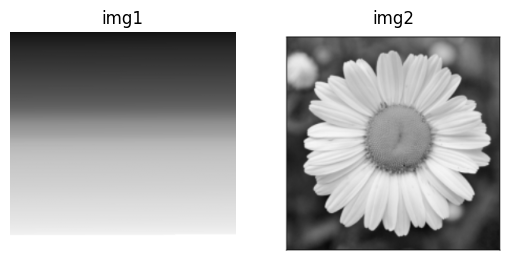

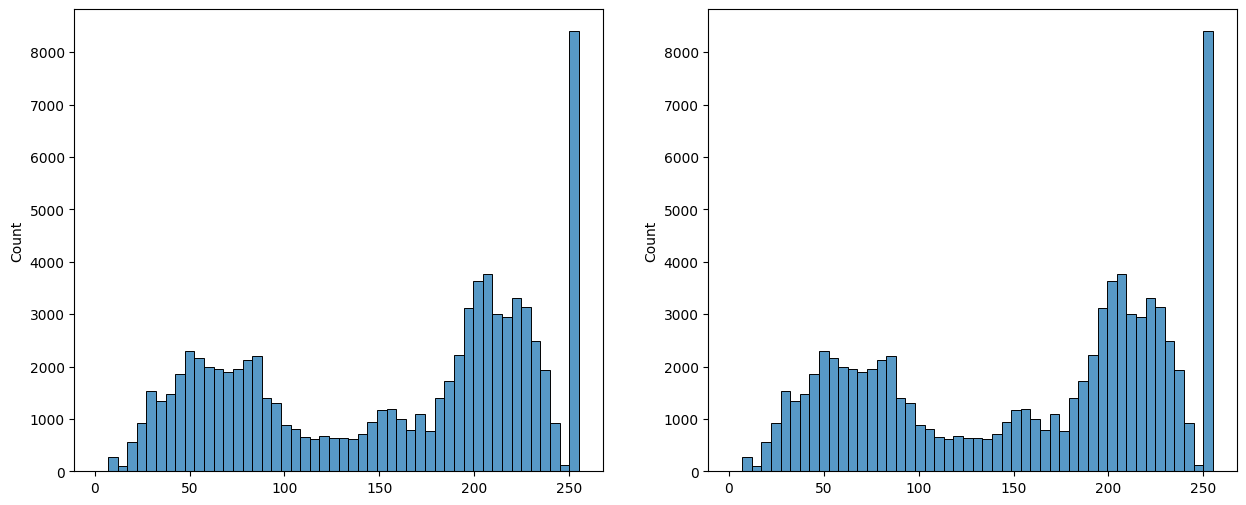

In [95]:
img1 = cv.imread('img1_tp.png', cv.IMREAD_GRAYSCALE)
img2 = cv.imread('img2_tp.png', cv.IMREAD_GRAYSCALE)

fig,axs = plt.subplots(1,2)
axs[0].imshow(img1[:,:], cmap='gray')
axs[0].set_title('img1')
axs[1].imshow(img2[:,:], cmap='gray')
axs[1].set_title('img2')
[ax.axis('off') for ax in axs]
plt.show()

fig,axs = plt.subplots(1,2, figsize=(15,6))
sns.histplot(img1.flatten(), ax=axs[0], bins=50)
sns.histplot(img2.flatten(), ax=axs[1], bins=50)
plt.show()

Los histogramas de las 2 imágenes son iguales. Se muestran con 50 bins, pero incluso teniendo 256 bins se puede ver exactamente la misma distribución. Esto se debe a que la imagen 1 es como ordenar todos los píxeles de la imagen 2 de más oscuro a más claro, pero la información que ve el histograma es exactamente la misma. 

Si bien esto parecería indicar que usar los histogramas como features para modelos de clasificación o detección es una mala práctica, creo que en algunos casos puede tener un uso importante, por ejemplo para detectar estrellas en una imagen del cielo nocturno: un pico de valores altos en el histograma podría ser un buen indicador de la presencia de una estrella (u otro elemento brilloso, como un satélite). Pero debe ser combinado con otras features para tener un buen modelo de detección.